In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import wandb
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from func import *

# class ModelCheckpoint:

# Initialize WandB
wandb.init(project="mlp-raw-features1")

# Load dataset
train_df = pd.read_csv('./../Dataset/train.csv')
test_df = pd.read_csv('./../Dataset/test.csv')

train_labels = train_df['label']
train_images = train_df.drop(columns=['label'])

# Reshape the images
train_images_reshaped = train_images.values.reshape(-1, 28, 28).astype(np.float32)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(train_images_reshaped, train_labels, test_size=0.2, random_state=42)

# Feature extraction: Edge Detection (Canny)
def raw_features(images):
    return images.reshape(images.shape[0], -1)

# Dataset class
class ImageDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        feature = self.features[idx]
        label = self.labels.iloc[idx]
        return torch.tensor(feature, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# MLP model
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(MLP, self).__init__()
        layers = []
        in_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(in_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))
            in_size = hidden_size
        layers.append(nn.Linear(hidden_sizes[-1], output_size))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


# Prepare the data and model
train_features = raw_features(X_train)
val_features = raw_features(X_val)

train_dataset = ImageDataset(train_features, y_train)
val_dataset = ImageDataset(val_features, y_val)

train_loader = DataLoader(train_dataset, batch_size=1264, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1264, shuffle=False)

input_size = train_features.shape[1]
hidden_sizes = [128, 64]
output_size = 10

model = MLP(input_size, hidden_sizes, output_size)

# Train the model

# def train_and_evaluate 

train_and_evaluate(model, train_loader, val_loader,num_epochs=20, learning_rate=0.001)

wandb: Currently logged in as: kaushalreddy207 (kaushalreddy207-iiit-hyderabad). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


New best model saved! (Validation Accuracy: 75.49%)
New best model saved! (Validation Accuracy: 81.09%)
New best model saved! (Validation Accuracy: 82.85%)
New best model saved! (Validation Accuracy: 84.39%)
New best model saved! (Validation Accuracy: 84.68%)
New best model saved! (Validation Accuracy: 84.90%)
New best model saved! (Validation Accuracy: 85.59%)
New best model saved! (Validation Accuracy: 85.71%)
New best model saved! (Validation Accuracy: 86.06%)
New best model saved! (Validation Accuracy: 86.27%)
New best model saved! (Validation Accuracy: 86.43%)
New best model saved! (Validation Accuracy: 86.74%)
New best model saved! (Validation Accuracy: 86.90%)
New best model saved! (Validation Accuracy: 86.92%)
New best model saved! (Validation Accuracy: 87.33%)


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

model = MLP(input_size, hidden_sizes, output_size)
# Load saved model weights
checkpoint = torch.load("./ckpt/mlp_model_best.pth")
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Epoch : {checkpoint['epoch']}, Val acc {checkpoint['val_acc']}")
def evaluate_model(model, test_loader, class_names=None):
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for features, labels in test_loader:
            outputs = model(features)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average='weighted')
    conf_matrix = confusion_matrix(all_labels, all_predictions)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    if class_names:
        plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
        plt.yticks(np.arange(len(class_names)), class_names, rotation=45)
    plt.tight_layout()
    
    # Save plot
    plt.savefig('confusion_matrix.png')
    
    # Log metrics to wandb
    wandb.log({
        "Test Accuracy": accuracy,
        "Test Precision": precision,
        "Test Recall": recall,
        "Test F1 Score": f1,
        "Confusion Matrix": wandb.Image('confusion_matrix.png')
    })
    
    # Return metrics dictionary
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": conf_matrix
    }


C:\Users\Pavan\AppData\Local\Temp\ipykernel_15972\1529468652.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./ckpt/mlp_model_best.pth")


Epoch : 17, Val acc 87.33333333333333


{'accuracy': 0.8799, 'precision': 0.8799308940733243, 'recall': 0.8799, 'f1_score': 0.8790652404429137, 'confusion_matrix': array([[820,   3,  25,  42,   1,   0, 100,   0,   8,   1],
       [  3, 983,   2,  10,   0,   1,   1,   0,   0,   0],
       [ 14,   2, 777,   9, 146,   0,  50,   0,   2,   0],
       [ 22,  19,  14, 899,  34,   1,   8,   0,   3,   0],
       [  0,   0,  58,  24, 876,   0,  41,   0,   1,   0],
       [  2,   0,   0,   0,   0, 937,   1,  30,   5,  25],
       [136,   6,  74,  26,  96,   0, 656,   0,   5,   1],
       [  0,   0,   0,   0,   0,  32,   0, 927,   1,  40],
       [  2,   0,   9,   2,   4,   1,  13,   2, 965,   2],
       [  0,   0,   0,   0,   0,   4,   0,  37,   0, 959]])}


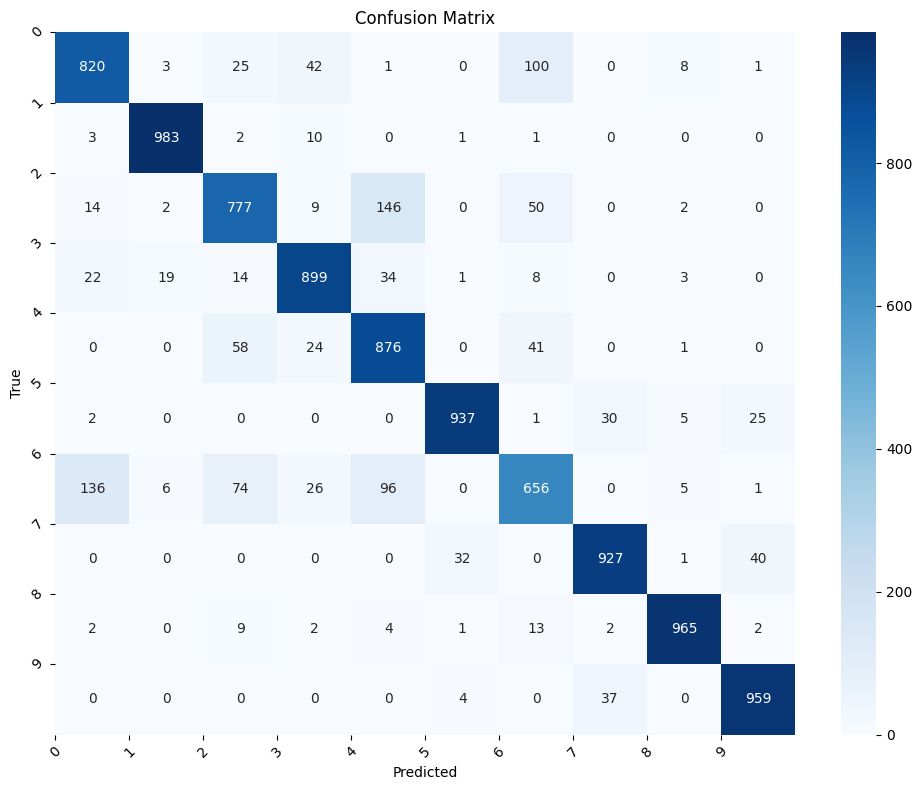

In [3]:

Y_test = test_df['label']
test_images = test_df.drop(columns=['label'])
X_test = test_images.values.reshape(-1, 28, 28)

X_test = raw_features(X_test)
test_dataset = ImageDataset(X_test, Y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class_names = list(range(10))  # For labels 0-9
metrics = evaluate_model(model, test_loader, class_names) #image and metrices are also logged in wandb
print(metrics)

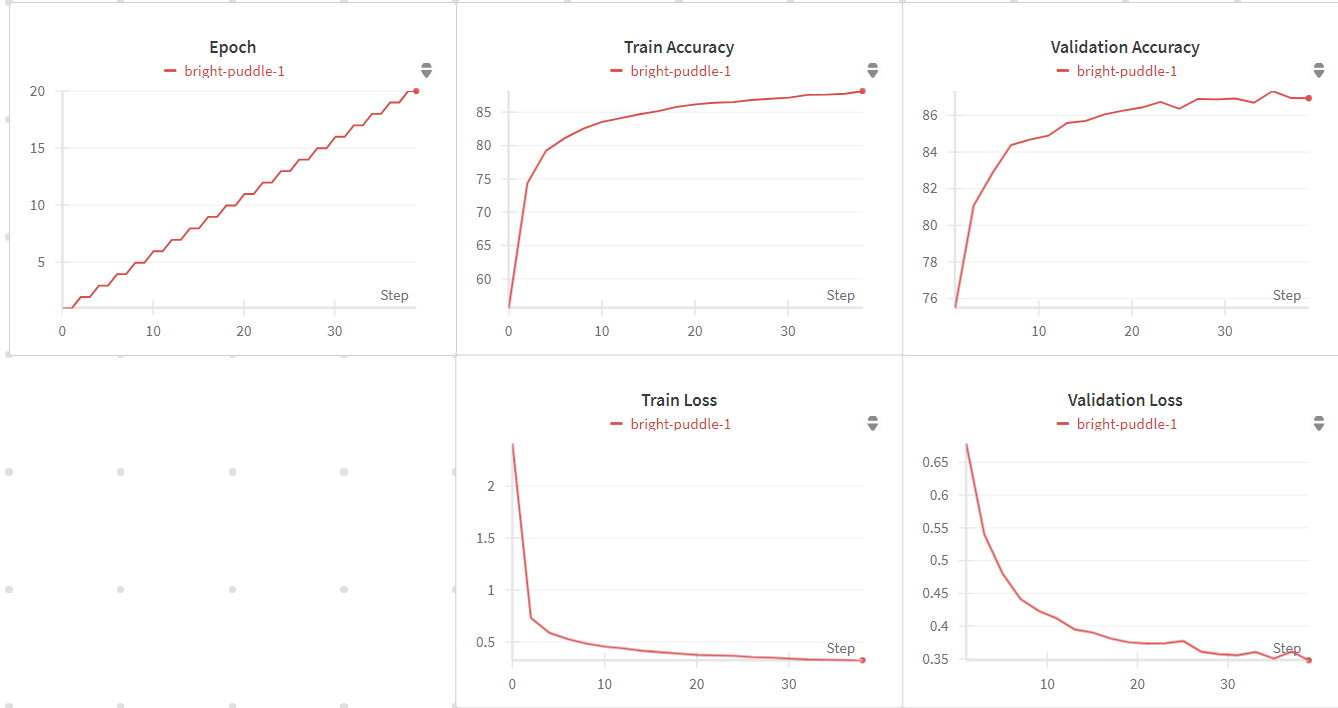